In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = [
    "TCS.NS","INFY.NS","HCLTECH.NS",
    "TATASTEEL.NS","HINDALCO.NS","JINDALSTEL.NS",
    "HDFCBANK.NS","ICICIBANK.NS","KOTAKBANK.NS",
    "HINDUNILVR.NS","ITC.NS","NESTLEIND.NS"
]

data = yf.download(
    tickers,
    start="2020-01-01",
    end="2025-12-31",
    interval="1d",
    auto_adjust=True
)
#data = yf.download(tickers,period = '5y')
prices = data["Close"]
prices = prices.dropna()

[*********************100%***********************]  12 of 12 completed


In [2]:
monthly_prices = prices.resample('M').last()
monthly_returns = monthly_prices.pct_change().dropna()
daily_returns = prices.pct_change().dropna()

/tmp/ipython-input-820/2917072134.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = prices.resample('M').last()


##Train/Test Split

In [3]:
train_monthly = monthly_returns.loc["2020-01-01":"2023-12-31"] #as mentioned in the assignment of banking crisis we took time period from
test_monthly  = monthly_returns.loc["2024-01-01":"2024-12-31"] #1st Jan 2020 to 2023 for training and the crisis period is also considered.
train_daily = daily_returns.loc["2020-01-01":"2023-12-31"]
test_daily  = daily_returns.loc["2024-01-01":"2024-12-31"]

In [4]:
train_monthly.shape

(47, 12)

##Mathematical Implementation of Ledoit-Wolf shrinkage estimator

In [5]:
R = train_monthly.values
T, N = R.shape
mean_vec = np.mean(R, axis=0)
X = R - mean_vec
S = (X.T @ X) / (T - 1)
mu = np.trace(S) / N
F = mu * np.eye(N)
gamma = np.sum((S - F)**2)
pi_hat = 0

for t in range(T):
    xt = X[t].reshape(-1,1)
    outer = xt @ xt.T
    pi_hat += np.sum((outer - S)**2)
pi_hat = pi_hat / ((T - 1)**2)
delta = pi_hat / gamma
delta = np.clip(delta, 0, 1)

print("T:", T)
print("Shrinkage intensity (T-1 scaling):", delta)
eigvals = np.linalg.eigvals(S)

kappa = np.max(eigvals) / np.min(eigvals)

print("Condition Number (kappa):", kappa)
print("Minimum Eigenvalue:", np.min(eigvals))
print("Maximum Eigenvalue:", np.max(eigvals))

mu_trace = np.trace(S) / N
F = mu_trace * np.eye(N)
Sigma_lw = delta * F + (1 - delta) * S
mu_vec = train_monthly.mean().values

inv_S = np.linalg.inv(S)

w_sample = inv_S @ mu_vec
w_sample = w_sample / np.sum(w_sample)

w_sample = pd.Series(w_sample, index=train_monthly.columns)

print("Maximum Sharpe Weights (Sample Cov):")
print(w_sample.sort_values())

inv_S_lw = np.linalg.inv(Sigma_lw)

w_lw = inv_S_lw @ mu_vec
w_lw = w_lw / np.sum(w_lw)

w_lw = pd.Series(w_lw, index=train_monthly.columns)

print("Maximum Sharpe Weights (Shrinkage):")
print(w_lw.sort_values())

print("Condition number Sample:", np.linalg.cond(S))
print("Condition number Shrinkage:", np.linalg.cond(Sigma_lw))

T: 47
Shrinkage intensity (T-1 scaling): 0.17053336250986678
Condition Number (kappa): 93.39719077272395
Minimum Eigenvalue: 0.0007064798738754642
Maximum Eigenvalue: 0.06598323555743668
Maximum Sharpe Weights (Sample Cov):
Ticker
HDFCBANK.NS     -0.461832
KOTAKBANK.NS    -0.287580
TATASTEEL.NS    -0.022639
HCLTECH.NS      -0.009331
INFY.NS          0.013962
HINDALCO.NS      0.030695
HINDUNILVR.NS    0.070879
JINDALSTEL.NS    0.217831
ICICIBANK.NS     0.242327
TCS.NS           0.288359
ITC.NS           0.319916
NESTLEIND.NS     0.597413
dtype: float64
Maximum Sharpe Weights (Shrinkage):
Ticker
KOTAKBANK.NS    -0.211827
HDFCBANK.NS     -0.208317
HINDALCO.NS     -0.001913
INFY.NS          0.012367
TATASTEEL.NS     0.068161
ICICIBANK.NS     0.094061
HINDUNILVR.NS    0.123360
HCLTECH.NS       0.128502
TCS.NS           0.168382
JINDALSTEL.NS    0.194142
ITC.NS           0.277111
NESTLEIND.NS     0.355971
dtype: float64
Condition number Sample: 93.39719077272345
Condition number Shrinkage: 2

##Bootstrapping and getting the range of Sample/Shrunk Covariance

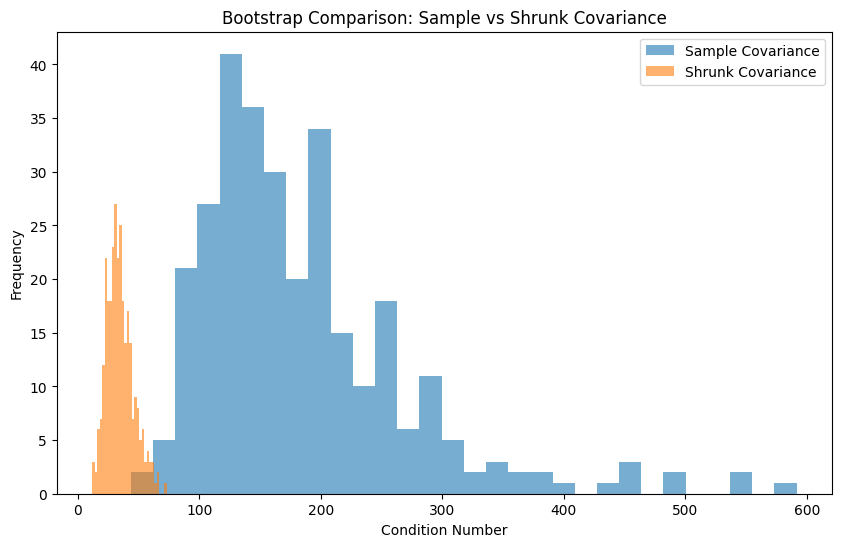

In [6]:
import numpy as np

def bootstrap_compare(returns, n_boot=300):
    kappa_sample_list = []
    kappa_lw_list = []

    for _ in range(n_boot):


        sample = returns.sample(frac=1, replace=True)
        Rb = sample.values
        Tb, N = Rb.shape

        mean_b = np.mean(Rb, axis=0)
        Xb = Rb - mean_b


        S_b = (Xb.T @ Xb) / (Tb - 1)
        eig_sample = np.linalg.eigvals(S_b)
        kappa_sample = np.max(eig_sample) / np.min(eig_sample)
        kappa_sample_list.append(kappa_sample)


        mu_trace = np.trace(S_b) / N
        F_b = mu_trace * np.eye(N)

        gamma_b = np.sum((S_b - F_b)**2)

        pi_hat_b = 0
        for t in range(Tb):
            xt = Xb[t].reshape(-1,1)
            outer = xt @ xt.T
            pi_hat_b += np.sum((outer - S_b)**2)

        pi_hat_b = pi_hat_b / ((Tb - 1)**2)

        delta_b = pi_hat_b / gamma_b
        delta_b = np.clip(delta_b, 0, 1)

        Sigma_lw_b = delta_b * F_b + (1 - delta_b) * S_b

        eig_lw = np.linalg.eigvals(Sigma_lw_b)
        kappa_lw = np.max(eig_lw) / np.min(eig_lw)
        kappa_lw_list.append(kappa_lw)

    return kappa_sample_list, kappa_lw_list


kappa_sample, kappa_lw = bootstrap_compare(train_monthly)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(kappa_sample, bins=30, alpha=0.6, label="Sample Covariance")
plt.hist(kappa_lw, bins=30, alpha=0.6, label="Shrunk Covariance")

plt.legend()
plt.xlabel("Condition Number")
plt.ylabel("Frequency")
plt.title("Bootstrap Comparison: Sample vs Shrunk Covariance")
plt.show()

##Heatmap of Sample and Shrunk Covariance

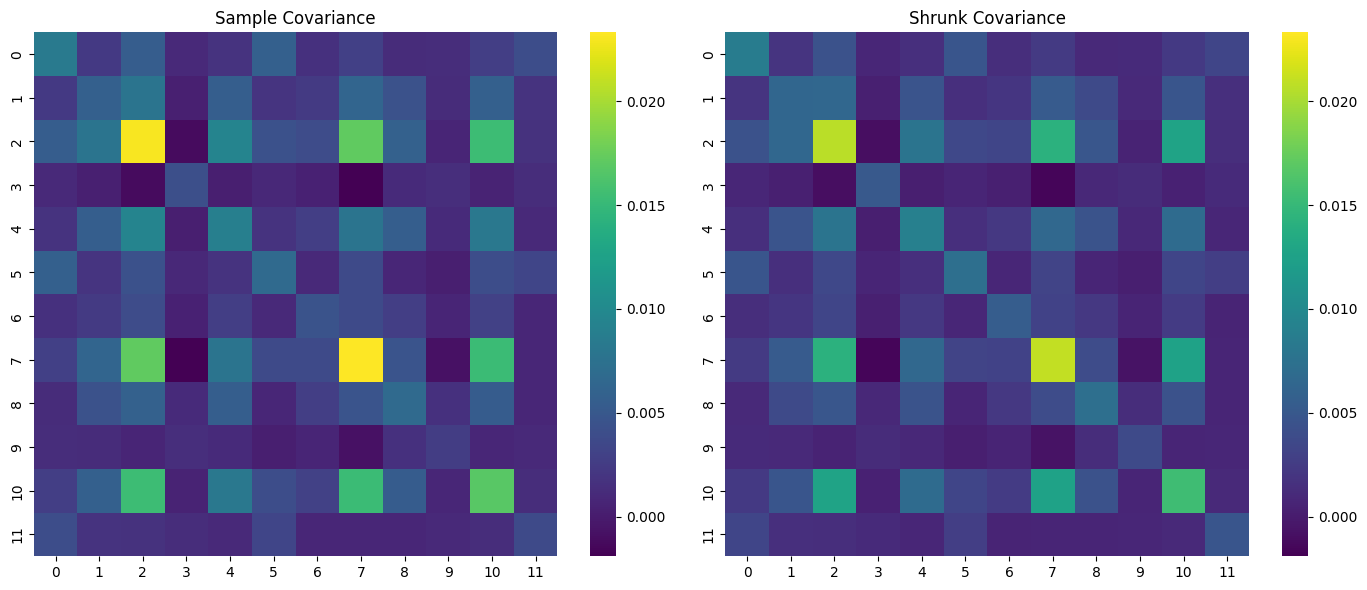

In [7]:
vmin = min(S.min().min(), Sigma_lw.min().min())
vmax = max(S.max().max(), Sigma_lw.max().max())
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.heatmap(S, ax=axes[0], cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title("Sample Covariance")

sns.heatmap(Sigma_lw, ax=axes[1], cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("Shrunk Covariance")

plt.tight_layout()
plt.show()

## HRP Dendrogram

/tmp/ipython-input-820/1207369799.py:4: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = linkage(dist, method='ward')


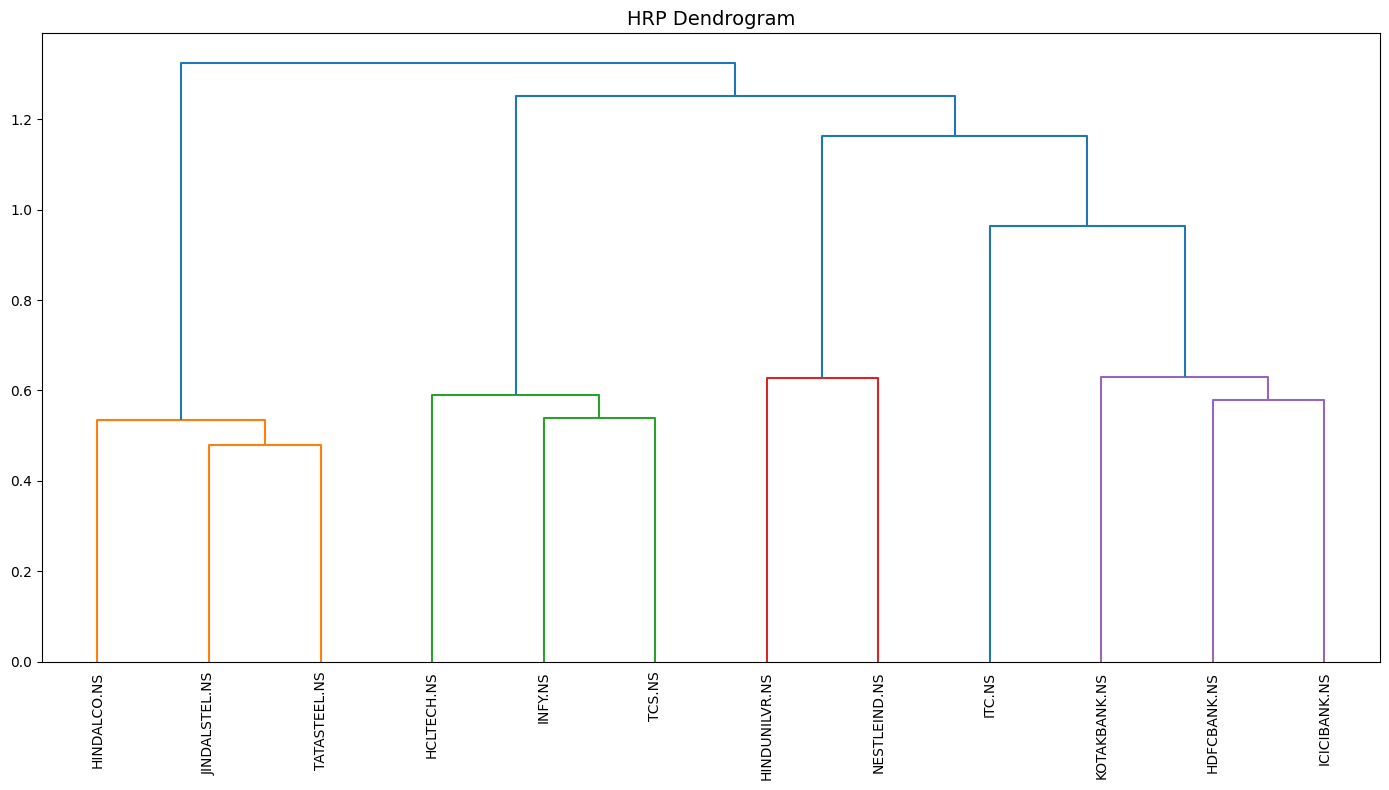

In [8]:
from scipy.cluster.hierarchy import linkage, dendrogram
corr = train_daily.corr()
dist = np.sqrt((1 - corr) / 2)
link = linkage(dist, method='ward')
plt.figure(figsize=(14,8))

dendrogram(
    link,
    labels=train_daily.columns,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title("HRP Dendrogram", fontsize=14)
plt.tight_layout()
plt.show()

##Quasi Diagonalisation

In [9]:
def get_quasi_diag(link):
    link = link.astype(int)
    sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
    num_items = link[-1, 3]

    while sort_ix.max() >= num_items:
        sort_ix.index = range(0, sort_ix.shape[0]*2, 2)
        df0 = sort_ix[sort_ix >= num_items]
        i = df0.index
        j = df0.values - num_items
        sort_ix[i] = link[j, 0]
        df1 = pd.Series(link[j, 1], index=i+1)
        sort_ix = pd.concat([sort_ix, df1])
        sort_ix = sort_ix.sort_index()
        sort_ix.index = range(sort_ix.shape[0])
    return sort_ix.tolist()
sort_ix = get_quasi_diag(link)
ordered_assets = train_daily.columns[sort_ix]
def get_cluster_var(cov, cluster_items):
    cov_slice = cov.loc[cluster_items, cluster_items]
    weights = np.ones(len(cluster_items)) / len(cluster_items)
    return weights @ cov_slice.values @ weights

def hrp_allocation(cov, ordered_assets):
    weights = pd.Series(1, index=ordered_assets)
    clusters = [ordered_assets]

    while len(clusters) > 0:
        cluster = clusters.pop(0)

        if len(cluster) <= 1:
            continue

        split = len(cluster) // 2
        left = cluster[:split]
        right = cluster[split:]

        var_left = get_cluster_var(cov, left)
        var_right = get_cluster_var(cov, right)

        alpha = 1 - var_left / (var_left + var_right)

        weights[left] *= alpha
        weights[right] *= 1 - alpha

        clusters.append(left)
        clusters.append(right)

    return weights
cov_daily = train_daily.cov()
weights_hrp = hrp_allocation(cov_daily, ordered_assets)

print("HRP Weights:")
print(weights_hrp.sort_values())
mu_daily = train_daily.mean().values
S_daily = train_daily.cov().values

inv_S_daily = np.linalg.inv(S_daily)
w_mpt = inv_S_daily @ mu_daily
w_mpt /= np.sum(w_mpt)

w_mpt = pd.Series(w_mpt, index=train_daily.columns)

print("MPT Weights:")
print(w_mpt.sort_values())
def compute_turnover(weights_list):
    turnover = 0
    for i in range(1, len(weights_list)):
        turnover += np.sum(np.abs(weights_list[i] - weights_list[i-1]))
    return turnover

HRP Weights:
Ticker
JINDALSTEL.NS    0.017638
TATASTEEL.NS     0.028530
HINDALCO.NS      0.043485
ICICIBANK.NS     0.048787
INFY.NS          0.059231
HDFCBANK.NS      0.069847
TCS.NS           0.078063
KOTAKBANK.NS     0.101988
HCLTECH.NS       0.103121
ITC.NS           0.115066
NESTLEIND.NS     0.159940
HINDUNILVR.NS    0.174304
dtype: float64
MPT Weights:
Ticker
KOTAKBANK.NS    -0.266307
HINDUNILVR.NS   -0.173228
HDFCBANK.NS     -0.115633
HINDALCO.NS     -0.108625
TCS.NS          -0.098445
INFY.NS          0.097904
ICICIBANK.NS     0.127111
JINDALSTEL.NS    0.147080
TATASTEEL.NS     0.169190
ITC.NS           0.387639
HCLTECH.NS       0.412866
NESTLEIND.NS     0.420448
dtype: float64


/tmp/ipython-input-820/1942855250.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.33006852 0.33006852 0.33006852 0.33006852 0.33006852 0.33006852]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  weights[left] *= alpha


In [10]:
window = 252
rebalance_step = 21

weights_mpt_list = []
weights_hrp_list = []

for start in range(0, len(train_daily) - window, rebalance_step):
    window_data = train_daily.iloc[start:start+window]
    mu = window_data.mean().values
    S = window_data.cov().values
    inv_S = np.linalg.inv(S)
    w_mpt = inv_S @ mu
    w_mpt /= np.sum(w_mpt)
    weights_mpt_list.append(w_mpt)
    corr = window_data.corr()
    dist = np.sqrt((1 - corr) / 2)
    link = linkage(dist, method='single')
    sort_ix = get_quasi_diag(link)
    ordered_assets = window_data.columns[sort_ix]
    cov = window_data.cov()
    w_hrp = hrp_allocation(cov, ordered_assets)
    weights_hrp_list.append(w_hrp.values)
def compute_turnover_with_drift(weights_list, returns_df, window, step):
    turnover = 0

    for i in range(1, len(weights_list)):

        w_prev = weights_list[i-1]
        w_new  = weights_list[i]

        # get return period between rebalances
        start_idx = i*step
        end_idx   = start_idx + step

        period_returns = returns_df.iloc[start_idx:end_idx].values

        # simulate drift
        w_drift = w_prev.copy()

        for r in period_returns:
            portfolio_return = np.dot(w_drift, r)
            w_drift = w_drift * (1 + r)
            w_drift = w_drift / (1 + portfolio_return)

        turnover += np.sum(np.abs(w_new - w_drift))

    return turnover / 2
turnover_mpt = compute_turnover_with_drift(weights_mpt_list, train_daily, window, rebalance_step)
turnover_hrp = compute_turnover_with_drift(weights_hrp_list, train_daily, window, rebalance_step)

print("MPT Turnover:", turnover_mpt)
print("HRP Turnover:", turnover_hrp)
#MPT Turnover: 45.546349362679436
#HRP Turnover: 6.793737223205454

/tmp/ipython-input-820/2715586391.py:17: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = linkage(dist, method='single')
/tmp/ipython-input-820/1942855250.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.72020013 0.72020013 0.72020013 0.72020013 0.72020013 0.72020013]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  weights[left] *= alpha
/tmp/ipython-input-820/2715586391.py:17: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = linkage(dist, method='single')
/tmp/ipython-input-820/1942855250.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.72151339 0.72151339 0.72151339 0.72151339 0.72151339 0.72151339]' 

MPT Turnover: 45.54630816511094
HRP Turnover: 6.793735454897992


/tmp/ipython-input-820/2715586391.py:17: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = linkage(dist, method='single')
/tmp/ipython-input-820/1942855250.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.24980682 0.24980682 0.24980682 0.24980682 0.24980682 0.24980682]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  weights[left] *= alpha


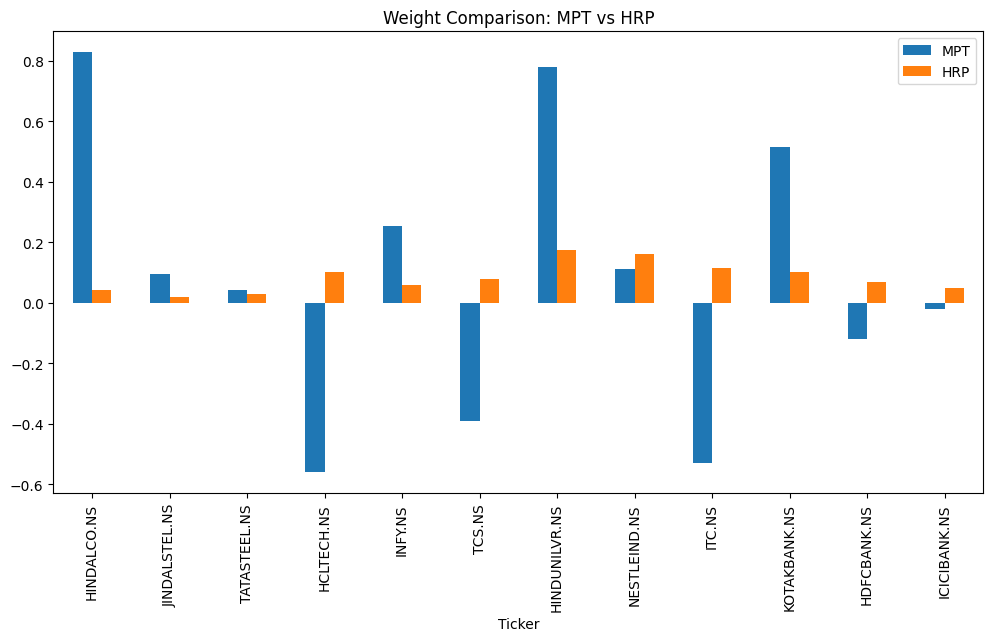

In [11]:
pd.DataFrame({
    "MPT": w_mpt,
    "HRP": weights_hrp
}).plot(kind='bar', figsize=(12,6))
plt.title("Weight Comparison: MPT vs HRP")
plt.show()

##Numerical Stabilization via Ridge Regularization in Covariance Inversion

/tmp/ipython-input-820/1077364542.py:29: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = linkage(dist, method='single')
/tmp/ipython-input-820/1942855250.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.71724092 0.71724092 0.71724092 0.71724092 0.71724092 0.71724092]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  weights[left] *= alpha
/tmp/ipython-input-820/1077364542.py:29: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = linkage(dist, method='single')
/tmp/ipython-input-820/1942855250.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.71432019 0.71432019 0.71432019 0.71432019 0.71432019 0.71432019]' 

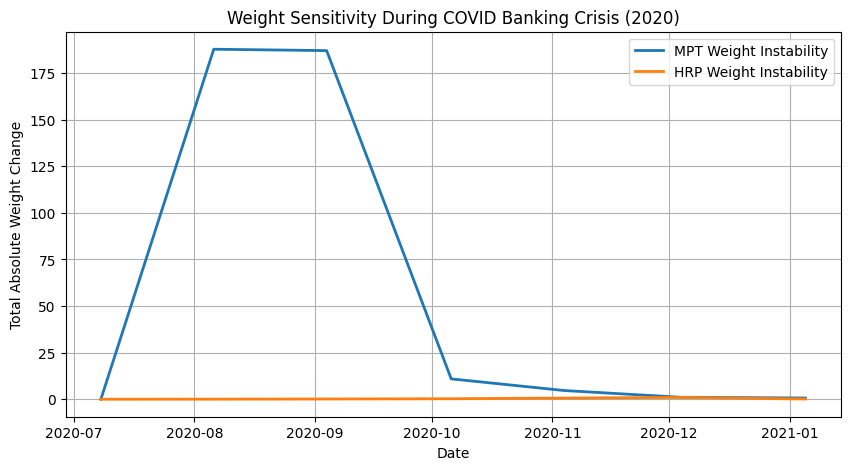

In [12]:
from scipy.cluster.hierarchy import linkage

window = 126
rebalance_step = 21

dates = []
mpt_weights = []
hrp_weights = []

for start in range(0, len(train_daily) - window, rebalance_step):

    end = start + window
    date = train_daily.index[end]
    window_data = train_daily.iloc[start:end]
    mu = window_data.mean().values
    S = window_data.cov().values
    ridge = 1e-4
    S_reg = S + ridge * np.eye(S.shape[0])
    w_mpt = np.linalg.solve(S_reg, mu)
    mu = 0.5 * mu

    w_mpt /= np.sum(w_mpt)

    corr = window_data.corr()
    dist = np.sqrt((1 - corr) / 2)
    link = linkage(dist, method='single')

    sort_ix = get_quasi_diag(link)
    ordered_assets = window_data.columns[sort_ix]

    cov = window_data.cov()
    w_hrp = hrp_allocation(cov, ordered_assets)

    dates.append(date)
    mpt_weights.append(w_mpt)
    hrp_weights.append(w_hrp.values)

mpt_df = pd.DataFrame(mpt_weights, index=dates, columns=train_daily.columns)
hrp_df = pd.DataFrame(hrp_weights, index=dates, columns=train_daily.columns)
start_available = mpt_df.index.min()
end_available = start_available + pd.DateOffset(months=6)

mpt_crisis = mpt_df.loc[start_available:end_available]
hrp_crisis = hrp_df.loc[start_available:end_available]
mpt_sensitivity = mpt_crisis.diff().abs().sum(axis=1)
hrp_sensitivity = hrp_crisis.diff().abs().sum(axis=1)

plt.figure(figsize=(10,5))
plt.plot(mpt_sensitivity, label="MPT Weight Instability", linewidth=2)
plt.plot(hrp_sensitivity, label="HRP Weight Instability", linewidth=2)

plt.title("Weight Sensitivity During COVID Banking Crisis (2020)")
plt.ylabel("Total Absolute Weight Change")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

##Banking Sector Weight Sensitivity

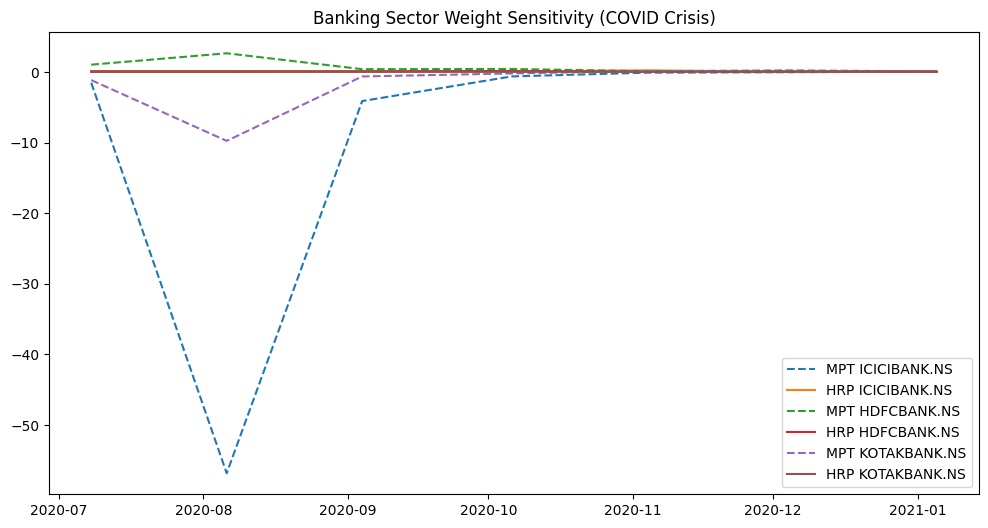

In [13]:
banks = ["ICICIBANK.NS", "HDFCBANK.NS", "KOTAKBANK.NS"]

plt.figure(figsize=(12,6))

for stock in banks:
    plt.plot(mpt_crisis[stock], linestyle='--', label=f"MPT {stock}")
    plt.plot(hrp_crisis[stock], label=f"HRP {stock}")

plt.title("Banking Sector Weight Sensitivity (COVID Crisis)")
plt.legend()
plt.show()

In [14]:
print("Gross leverage:", np.sum(np.abs(w_mpt)))

Gross leverage: 1.9167603390518322
